## Лабораторная работа 3
### Линейные структуры данных

#### Связный список

№ 1
(3 балла)
Возьмите реализацию класса UnorderedList из лекционных материалов и выполните
следующие доработки:
1. Реализуйте оставшиеся методы этого класса append(item), index(item),
insert(pos,item), pop(), pop(pos). Требования к работе этих методов посмотрите в
лекционной презентации.
2. Реализуйте метод __str__, чтобы содержимое списка отображалось в Python-стиле (в
квадратных скобках).
3. Реализуйте метод “среза”. Он должен принимать два параметра (start и stop) и
возвращать копию списка, начиная с позиции start и заканчивая (но не включая!)
позицией stop. <br>
Все выполненные доработки должны быть протестированы.

In [21]:
class Node:
    def __init__(self,initdata):
        self.data = initdata
        self.next = None

    def getData(self):
        return self.data

    def getNext(self):
        return self.next

    def setData(self,newdata):
        self.data = newdata

    def setNext(self,newnext):
        self.next = newnext


class UnorderedList:
    def __init__(self):
        self.head = None

    def isEmpty(self):
        return self.head == None

    def add(self,item):
        temp = Node(item)
        temp.setNext(self.head)
        self.head = temp

    def remove(self,item):
        current = self.head
        previous = None
        found = False
        while not found:
            if current.getData() == item:
                found = True
            else:
                previous = current
                current = current.getNext()

        if previous == None:
            self.head = current.getNext()
        else:
            previous.setNext(current.getNext())

    def search(self,item):
        current = self.head
        found = False
        while current != None and not found:
            if current.getData() == item:
                found = True
            else:
                current = current.getNext()

        return found

    def size(self):
        current = self.head
        count = 0
        while current != None:
            count = count + 1
            current = current.getNext()

        return count

    def append(self,item):
        temp = Node(item)
        if self.head == None:
            self.head = temp
        else:
            current = self.head
            while current.getNext() != None:
                current = current.getNext()
            current.setNext(temp)

    def index(self, item):
        current = self.head
        pos = 0
        found = False
        while current != None and not found:
            if current.getData() == item:
                found = True
            else:
                current = current.getNext()
                pos += 1

        if found:
            return pos
        else:
            print("Позиция вне диапазона")

    def insert(self, pos, item):
        if pos < 0 or pos > self.size():
            print("Позиция вне диапазона")

        if pos == 0:
            self.add(item)
        else:
            temp = Node(item)
            current = self.head
            previous = None
            current_pos = 0

            while current_pos < pos:
                previous = current
                current = current.getNext()
                current_pos += 1

            previous.setNext(temp)
            temp.setNext(current)

    def pop(self, pos=None):
        if self.head is None:
            print("Попытка извлечения из пустого списка")

        if pos is None:
            return self.pop(self.size() - 1)
        else:
            if pos < 0 or pos >= self.size():
                print("Позиция вне диапазона")

            if pos == 0:
                item = self.head.getData()
                self.head = self.head.getNext()
                return item
            else:
                current = self.head
                previous = None
                current_pos = 0

                while current_pos < pos:
                    previous = current
                    current = current.getNext()
                    current_pos += 1

                item = current.getData()
                previous.setNext(current.getNext())
                return item

    def __str__(self):
        elements = []
        current = self.head

        while current != None:
            elements.append(str(current.getData()))
            current = current.getNext()

        return "[" + ", ".join(elements) + "]"

    def slice(self, start, stop):

        if start < 0 or stop > self.size() or start > stop:
            raise IndexError("Некорректные значения start и stop")

        result = UnorderedList()
        current = self.head
        pos = 0

        # Пропускаем элементы до start
        while pos < start:
            current = current.getNext()
            pos += 1

        # Добавляем элементы от start до stop-1
        temp_list = []
        while pos < stop:
            temp_list.append(current.getData())
            current = current.getNext()
            pos += 1

        # Добавляем элементы в обратном порядке, чтобы сохранить порядок
        for item in reversed(temp_list):
            result.add(item)

        return result

if __name__ == "__main__":

    my_list = UnorderedList()

    my_list.add(1)
    my_list.add(2)
    my_list.add(3)
    print(f"После add: {my_list}")

    my_list.append(4)
    print(f"После append: {my_list}")

    print(f"Индекс 2: {my_list.index(2)}")
    print(f"Индекс 4: {my_list.index(4)}")

    my_list.insert(1, 5)
    print(f"После insert(1, 5): {my_list}")

    print(f"pop(): {my_list.pop()}, список: {my_list}")
    print(f"pop(1): {my_list.pop(1)}, список: {my_list}")

    my_list.append(6)
    my_list.append(7)
    print(f"Полный список: {my_list}")

    slice_result = my_list.slice(1, 4)
    print(f"Срез [1:4]: {slice_result}")






После add: [3, 2, 1]
После append: [3, 2, 1, 4]
Индекс 2: 1
Индекс 4: 3
После insert(1, 5): [3, 5, 2, 1, 4]
pop(): 4, список: [3, 5, 2, 1]
pop(1): 5, список: [3, 2, 1]
Полный список: [3, 2, 1, 6, 7]
Срез [1:4]: [2, 1, 6]


№ 2
(2 балла)
Напишите функцию move_to_front для чтения строк с клавиатуры и сохранения их в
связном списке без повторов. Пользователь последовательно вводит с клавиатуры n строк.
При вводе строки, которая раньше не встречалась, вставьте ее в начало списка. При вводе
уже внесенной строки удалите ее из списка и снова вставьте в начало.
Такая функция реализует стратегию «сдвиг в начало», которая применяется в кешировании,
при сжатии данных и т.д.

In [14]:
def move_to_front(n):
    my_list_ = UnorderedList()
    for s in range(n):
        item = input()
        if my_list_.isEmpty():
            my_list_.add(item)
        elif(my_list_.search(item) == False):
            my_list_.add(item)
        else:
            idx = my_list_.index(item)
            my_list_.pop(idx)
            my_list_.add(item)

    return my_list_


print(move_to_front(5))

[jjj, hello, world]


№ 3
(2 балла)
Напишите функцию, которая принимает в качестве аргумента первый узел односвязного
списка, обращает порядок элементов списка (с разрушением исходного) и возвращает в
качестве результата первый узел полученного списка. Разработайте два варианта решения
этой задачи: 1) итеративный и 2) рекурсивный.

In [15]:
my_list = UnorderedList()
my_list.add(1)
my_list.add(2)
my_list.add(3)

def reverse_iterative(head):
    previous = None
    current = head

    while current != None:
        next_node = current.next
        current.next = previous
        previous = current
        current = next_node

    return previous

def reverse_recursive(head):

    if head is None or head.next is None:
        return head

    new_head = reverse_recursive(head.next)

    head.next.next = head
    head.next = None
    return new_head



node1 = Node(1)
node2 = Node(2)
node3 = Node(3)

node1.next = node2
node2.next = node3

print(reverse_iterative(node1).getData())
print(reverse_recursive(node1).getData())


3
1


№ 4
(3 балла)
Используя реализацию связного списка из задания № 1 (класс UnorderedList), реализуйте
следующие линейные структуры (необходимый набор методов посмотрите в лекционной
презентации):
1. Стек.
2. Очередь.
3. Дек.
Проведите тестирование реализованных линейных структур.
Продумайте и проведите показательный эксперимент, сравнивающий производительность
стека, очереди или дека, основанных на списках Python, с реализациями на основе
связанного списка. Например, для сравнения можно взять какую-либо операцию
выбранной линейной структуры.


In [22]:
class Stack():
    def __init__(self):
        self.items = UnorderedList()

    def push(self, item):
        self.items.add(item)

    def pop(self):
        if self.isEmpty():
            print("Попытка извлечения из пустого стека")
        return self.items.pop(0)

    def peek(self):
        if self.isEmpty():
            raise IndexError("Попытка просмотра вершины пустого стека")
        return self.items.head.getData()

    def isEmpty(self):
        return self.items.isEmpty()

    def size(self):
        return self.items.size()

    def __str__(self):
        return self.items.__str__()

class Queue():
    def __init__(self):
        self.items = UnorderedList()

    def enqueue(self, item):
        self.items.append(item)

    def dequeue(self):
        if self.isEmpty():
            print("Попытка извлечения из пустого стека")
        return self.items.pop(0)

    def isEmpty(self):
        return self.items.isEmpty()

    def size(self):
        return self.items.size()

    def __str__(self):
        return self.items.__str__()


class Deque():
    def __init__(self):
        self.items = UnorderedList()

    def addFront(self, item):
        self.items.add(item)

    def addRear(self, item):
        self.items.append(item)

    def removeFront(self):
        if self.isEmpty():
            print("Попытка извлечения из пустого стека")
        return self.items.pop(0)

    def removeRear(self):
        if self.isEmpty():
            print("Попытка извлечения из пустого стека")
        return self.items.pop()

    def isEmpty(self):
        return self.items.isEmpty()

    def size(self):
        return self.items.size()

    def __str__(self):
        return self.items.__str__()




def test_structures():

    # Тестирование стека
    print("\n1. ТЕСТ СТЕКА:")
    s = Stack()
    s.push(1)
    s.push(2)
    s.push(3)
    print(f"Стек после добавления 1,2,3: {s}")
    print(f"Вершина стека: {s.peek()}")
    print(f"Извлечен: {s.pop()}")
    print(f"Стек после pop: {s}")
    print(f"Размер: {s.size()}")
    print(f"Пустой: {s.isEmpty()}")

    # Тестирование очереди
    print("\n2. ТЕСТ ОЧЕРЕДИ:")
    q = Queue()
    q.enqueue(1)
    q.enqueue(2)
    q.enqueue(3)
    print(f"Очередь после добавления 1,2,3: {q}")
    print(f"Извлечен: {q.dequeue()}")
    print(f"Очередь после dequeue: {q}")

    # Тестирование дека
    print("\n3. ТЕСТ ДЕКА:")
    d = Deque()
    d.addFront(1)
    d.addRear(2)
    d.addFront(0)
    d.addRear(3)
    print(f"Дек после операций: {d}")
    print(f"removeFront: {d.removeFront()}")
    print(f"removeRear: {d.removeRear()}")
    print(f"Дек после извлечения: {d}")

test_structures()





1. ТЕСТ СТЕКА:
Стек после добавления 1,2,3: [3, 2, 1]
Вершина стека: 3
Извлечен: 3
Стек после pop: [2, 1]
Размер: 2
Пустой: False

2. ТЕСТ ОЧЕРЕДИ:
Очередь после добавления 1,2,3: [1, 2, 3]
Извлечен: 1
Очередь после dequeue: [2, 3]

3. ТЕСТ ДЕКА:
Дек после операций: [0, 1, 2, 3]
removeFront: 0
removeRear: 3
Дек после извлечения: [1, 2]


1. Реализация структур на стандартном списке Python

Функции для тестирования производительности

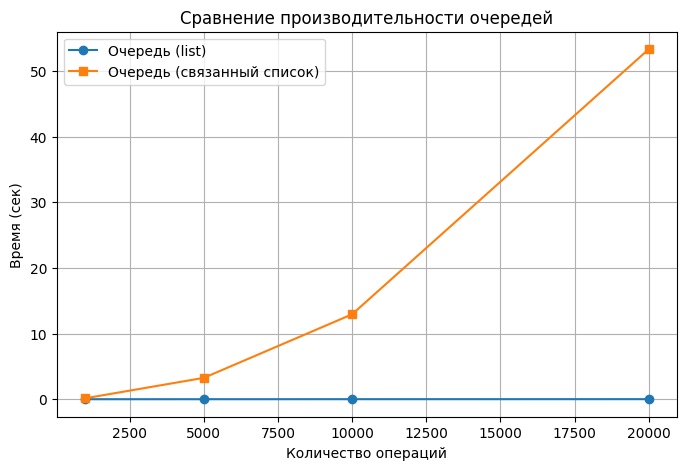

In [17]:
import time
import matplotlib.pyplot as plt

class ListStack:
    def __init__(self):
        self.items = []
    def push(self, item):
        self.items.append(item)
    def pop(self):
        return self.items.pop()

class ListQueue:
    def __init__(self):
        self.items = []
    def enqueue(self, item):
        self.items.append(item)
    def dequeue(self):
        return self.items.pop(0)

class ListDeque:
    def __init__(self):
        self.items = []
    def addFront(self, item):
        self.items.insert(0, item)
    def addRear(self, item):
        self.items.append(item)
    def removeFront(self):
        return self.items.pop(0)
    def removeRear(self):
        return self.items.pop()

def measure_time(structure_class, operation, n):
    s = structure_class()
    start = time.time()
    for i in range(n):
        operation(s, i)
    end = time.time()
    return end - start

def run_experiment():
    ns = [1000, 5000, 10000, 20000]
    list_times = []
    linked_times = []


    for n in ns:
        # Очередь на list
        t1 = measure_time(ListQueue, lambda q, i: q.enqueue(i), n)
        t2 = measure_time(ListQueue, lambda q, i: q.dequeue() if q.items else q.enqueue(i), n)

        # Очередь на UnorderedList
        t3 = measure_time(Queue, lambda q, i: q.enqueue(i), n)
        t4 = measure_time(Queue, lambda q, i: q.dequeue() if not q.isEmpty() else q.enqueue(i), n)

        list_times.append(t1 + t2)
        linked_times.append(t3 + t4)

    # Построим график
    plt.figure(figsize=(8,5))
    plt.plot(ns, list_times, 'o-', label="Очередь (list)")
    plt.plot(ns, linked_times, 's-', label="Очередь (связанный список)")
    plt.xlabel("Количество операций")
    plt.ylabel("Время (сек)")
    plt.title("Сравнение производительности очередей")
    plt.legend()
    plt.grid(True)
    plt.show()

run_experiment()


№ 5
(2 балла)
Реализуйте класс DoubleList для построения двухсвязных списков, в которых каждый узел
содержит ссылку на узел, предшествующий ему в списке, и ссылку на следующий узел.
Класс должен иметь следующие методы: проверка списка на пустоту, поиск элемента,
размер списка, вставка в начало, вставка в конец, удаление из начала, удаление из конца,
вставка перед указанным узлом, вставка после указанного узла, удаление указанного узла.
Проведите тестирование методов реализованного класса.


In [18]:
class Node:
    def __init__(self, next=None, prev=None, data=None):
        self.next = next
        self.prev = prev
        self.data = data

class DoubleList():
    def __init__(self):
        self.head = None
        self.tail = None
        self.length = 0

    def isEmpty(self):
        return self.head is None

    def search(self, item):
        current = self.head
        while current:
            if current.data == item:
                return current
            current = current.next
        return None

    def size(self):
        return self.length

    def add(self, item):
        new_node = Node(data=item)
        if self.isEmpty():
            self.head = new_node
            self.tail = new_node
        else:
            new_node.next = self.head
            self.head.prev = new_node
            self.head = new_node
        self.length += 1

    def append(self, item):
        new_node = Node(data=item)
        if self.isEmpty():
            self.head = new_node
            self.tail = new_node
        else:
            new_node.prev = self.tail
            self.tail.next = new_node
            self.tail = new_node
        self.length += 1

    def remove_front(self):
        if self.isEmpty():
            print("Попытка удаления из пустого списка")
            return None

        removed_data = self.head.data
        if self.head == self.tail:
            self.head = None
            self.tail = None
        else:
            self.head = self.head.next
            self.head.prev = None
        self.length -= 1
        return removed_data

    def remove_rear(self):
        if self.isEmpty():
            print("Попытка удаления из пустого списка")
            return None

        removed_data = self.tail.data
        if self.head == self.tail:
            self.head = None
            self.tail = None
        else:
            self.tail = self.tail.prev
            self.tail.next = None
        self.length -= 1
        return removed_data

    def remove_node(self, node):
        if node is None:
            return None

        if node == self.head:
            return self.remove_front()
        elif node == self.tail:
            return self.remove_rear()
        else:
            node.prev.next = node.next
            node.next.prev = node.prev
            self.length -= 1
            return node.data

    def insert_before(self, target_node, item):
        if target_node is None:
            print("Целевой узел не может быть None")
            return
        if target_node == self.head:
            self.add(item)
            return
        new_node = Node(data=item)
        new_node.prev = target_node.prev
        new_node.next = target_node
        target_node.prev.next = new_node
        target_node.prev = new_node
        self.length += 1

    def insert_after(self, target_node, item):
        if target_node is None:
            print("Целевой узел не может быть None")
            return
        if target_node == self.tail:
            self.append(item)
            return
        new_node = Node(data=item)
        new_node.next = target_node.next
        new_node.prev = target_node
        target_node.next.prev = new_node
        target_node.next = new_node
        self.length += 1

    def pop(self, pos=None):
        if self.isEmpty():
            print("Попытка удаления из пустого списка")
            return None

        if pos is None:
            return self.remove_rear()
        else:
            if pos < 0 or pos >= self.length:
                print("Позиция вне диапазона")
                return None

            if pos == 0:
                return self.remove_front()
            elif pos == self.length - 1:
                return self.remove_rear()
            else:
                current = self.head
                for _ in range(pos):
                    current = current.next
                return self.remove_node(current)

    def __str__(self):
        elements = []
        current = self.head
        while current:
            elements.append(str(current.data))
            current = current.next
        return "[" + " ".join(elements) + "]"


dl = DoubleList()

print("\n1. Добавление элементов:")
dl.add(1)
dl.add(2)
dl.append(3)
dl.append(4)
print(f"Список: {dl}")
print(f"Размер: {dl.size()}")

print("\n2. Поиск элементов:")
node = dl.search(3)
print(f"Поиск 3: {node.data if node else 'Не найден'}")

print("\n3. Вставка перед/после:")
node = dl.search(3)
if node:
    dl.insert_before(node, 99)
    dl.insert_after(node, 88)
print(f"После вставки: {dl}")

print("\n4. Удаление:")
dl.remove_front()
dl.remove_rear()
print(f"После удаления начала и конца: {dl}")

print("\n5. Добавляем элементы для теста pop:")
dl.add(5)
dl.add(6)
dl.append(7)
print(f"Список перед pop: {dl}")

print("\n6. Удаление по индексу:")
popped = dl.pop(1)
print(f"Удален элемент: {popped}")
print(f"Список после pop(1): {dl}")

print("\n7. Удаление последнего (pop без аргументов):")
popped = dl.pop()
print(f"Удален элемент: {popped}")
print(f"Список после pop(): {dl}")


1. Добавление элементов:
Список: [2 1 3 4]
Размер: 4

2. Поиск элементов:
Поиск 3: 3

3. Вставка перед/после:
После вставки: [2 1 99 3 88 4]

4. Удаление:
После удаления начала и конца: [1 99 3 88]

5. Добавляем элементы для теста pop:
Список перед pop: [6 5 1 99 3 88 7]

6. Удаление по индексу:
Удален элемент: 5
Список после pop(1): [6 1 99 3 88 7]

7. Удаление последнего (pop без аргументов):
Удален элемент: 7
Список после pop(): [6 1 99 3 88]


## Стек

№ 6
(2 балла)
В HTML у каждого тега существуют открывающая и закрывающая формы, которые должны
быть сбалансированы, чтобы адекватно описывать веб-документ. Вот пример очень
простого веб-документа:
<html>
 <head>
 <title>
 Example
 </title>
 </head>
 <body>
 <h1>Hello, world</h1>
 </body>
</html>
Напишите программу, которая, используя структуру данных стек, проверит HTML
документ на соответствие открывающих и закрывающих тегов.
За основу решения можно взять алгоритм проверки скобочной последовательности из
лекционных материалов.


In [26]:
def parChecker(str):
    stck = Stack()
    balanced = True
    index = 0
    while index < len(str) and balanced:
        char = str[index]
        if char == '<':
            stck.push(char)
        else:
            if stck.isEmpty():
                balanced = False
            elif char == '>':
                stck.pop()
        index += 1
    if balanced == True and stck.isEmpty():
        return True
    else: return False


print(parChecker("<>>>>"))
print(parChecker("<>>><,<<>>"))
print(parChecker("<<<><><>>>"))

False
False
True


№ 7
(2 балла)
Стековый калькулятор - это устройство (реальное или виртуальное), которое вычисляет
значения арифметических выражений, записанных в постфиксной форме (также она носит
название Обратная польская запись — Википедия (wikipedia.org)). Стековым он называется
так как действует по следующим правилам: если нам встречается число - мы должны
поместить его в стек; если знак операции - мы должны достать из стека столько чисел,
сколько необходимо для выполнения данной операции и выполнить ее.
Именно так и работает т.н. математический сопроцессор (например, в INtel8086+AMD64)-
часть ЦП, отвечающая за операции над числами с плавающей запятой.
Реализуйте стековый калькулятор. Напишите программу, которая читает выражение в
обратной польской нотации и выводит получившееся значение или пишет, что выражение
составлено не корректно (если оно некорректно).

In [58]:
def stackCalc(expr):
    stack = Stack()
    tokens = expr.split()

    for token in tokens:
        try:
            num = int(token)
            stack.push(num)
        except ValueError:
            if stack.size() < 2:
                print("Недостаточно операндов")
                return None

            b = stack.pop()
            a = stack.pop()

            if token == '+':
                stack.push(a + b)
            elif token == '-':
                stack.push(a - b)
            elif token == '*':
                stack.push(a * b)
            elif token == '/':
                if b == 0:
                    print("Деление на ноль — выражение составлено некорректно")
                    return None
                stack.push(a / b)
            else:
                print(f"Неизвестная операция: {token}")
                return None

    if stack.size() != 1:
        print("Выражение составлено некорректно")
        return None

    return stack.pop()


print(stackCalc('1 2 -'))
print(stackCalc('10 20 +'))
print(stackCalc('5 1 2 + 4 * + 3 -'))
print(stackCalc('1 0 /'))


-1
30
14
Деление на ноль — выражение составлено некорректно
None


## Очередь

№ 8
(4 балла)
Используя структуру данных очередь и пример из лекционных материалов, создайте
симуляцию ситуации из реальной жизни согласно своему варианту:
<br>
Вариант 5. Студенты, сдающие экзамен преподавателю.
<br>
Обязательно укажите сделанные вами предположения и предоставьте любые
вероятностные данные, которые нужно будет рассмотреть в качестве части сценария.

In [69]:
import random

class Queue:
    def __init__(self):
        self.items = []

    def isEmpty(self):
        return self.items == []

    def enqueue(self, item):
        self.items.insert(0, item)

    def dequeue(self):
        return self.items.pop()

    def size(self):
        return len(self.items)


class Student:
    def __init__(self, time):
        self.timestamp = time  # время прихода студента
        self.exam_time = random.randint(5, 20)  # длительность сдачи экзамена (минуты)

    def waitTime(self, current_time):
        return current_time - self.timestamp


class Teacher:
    def __init__(self):
        self.current_student = None
        self.time_remaining = 0

    def busy(self):
        return self.current_student is not None

    def startNext(self, student):
        self.current_student = student
        self.time_remaining = student.exam_time

    def tick(self):
        if self.current_student:
            self.time_remaining -= 1
            if self.time_remaining <= 0:
                self.current_student = None


def simulation(total_minutes, arrival_rate):
    teacher = Teacher()
    student_queue = Queue()
    waiting_times = []

    for current_minute in range(total_minutes):
        # С вероятностью arrival_rate создаём нового студента
        if random.randint(1, arrival_rate) == arrival_rate:
            student = Student(current_minute)
            student_queue.enqueue(student)

        # Если преподаватель свободен и есть студенты — берёт следующего
        if (not teacher.busy()) and (not student_queue.isEmpty()):
            next_student = student_queue.dequeue()
            waiting_times.append(next_student.waitTime(current_minute))
            teacher.startNext(next_student)

        teacher.tick()

    average_wait = sum(waiting_times) / len(waiting_times) if waiting_times else 0
    print(f"Среднее время ожидания: {average_wait:.2f} мин.")
    print(f"Количество студентов, успевших сдать: {len(waiting_times)}")
    print(f"Студентов осталось в очереди: {student_queue.size()}")


simulation(total_minutes=120, arrival_rate=3)
simulation(total_minutes=120, arrival_rate=15)


Среднее время ожидания: 48.11 мин.
Количество студентов, успевших сдать: 9
Студентов осталось в очереди: 31
Среднее время ожидания: 6.67 мин.
Количество студентов, успевших сдать: 6
Студентов осталось в очереди: 4
